In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Implementation of MCP Neuron for AND and OR Function.

In [20]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): A state of neuron 1 or 0 for the particular inputs.
    """
    assert len(X1) == len(X2)

    # Element-wise sum of inputs
    sums = [a + b for a, b in zip(X1, X2)]

    # Create list for neuron states
    state_neuron = []

    # Apply threshold: if sum >= T -> 1 else 0
    for s in sums:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


In [21]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


#  Question- 1: List out all the limitations of MCP- Neurons.

MCP neurons use fixed, hand‑crafted thresholds and do not have a built‑in learning rule to automatically adjust their behavior from data.
​

The model only computes a simple sum of inputs followed by a hard threshold, so it cannot capture more complex or non‑linear relationships between inputs and outputs.
​

A single MCP neuron can only represent linearly separable functions, which means it cannot solve problems like XOR where no straight line can perfectly separate the classes.
​

All inputs are treated in a very simplified way (no graded activation, no continuous output), so it ignores many important biological neuron properties and dynamics.
​

Because of these limitations, MCP neurons cannot scale well to real‑world tasks and mainly serve as a historical, conceptual model rather than a practical learning system.

# Question- 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}

For XOR, the output should be 1 only when exactly one of the inputs is 1, and 0 otherwise, so the positive and negative examples are not linearly separable.
​

A single MCP neuron uses one global threshold on the sum of inputs, which always corresponds to a straight line decision boundary in the input space.
​

Since XOR requires a boundary that “bends” around the points, no single threshold on a simple sum of x₁ and x₂ can separate the XOR outputs correctly.
​

Therefore, you cannot write a single MCP if–else rule that correctly implements XOR for all input combinations using only one neuron.
​

To implement XOR, you would need to combine multiple MCP neurons in layers (for example, two hidden MCPs feeding into an output MCP), which goes beyond the basic single‑neuron MCP model.

In [22]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)

    # Element-wise sum of inputs
    sums = [a + b for a, b in zip(X1, X2)]

    # Create list for neuron states
    state_neuron = []

    # Apply threshold: if sum >= T -> 1 else 0
    for s in sums:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


In [23]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/My Drive/AI and Machine Learning/Workshop 3/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


# Question- 1: What does the shape of X represent?

The first dimension 12665 is the number of samples, so there are 12665 digit images in the 0 vs 1 subset.
​

The second dimension 784 is the number of features per sample, because each 28×28 image has been flattened into a vector of 784 pixel values.


# Question- 2: What does the shape of Y represent?

The shape (12665,) means there is one label for each of the 12665 images in the dataset.
​

Each entry in y is either 0 or 1 and indicates the true class (digit 0 or digit 1) for the corresponding row in X.

### Viewing the Dataset.

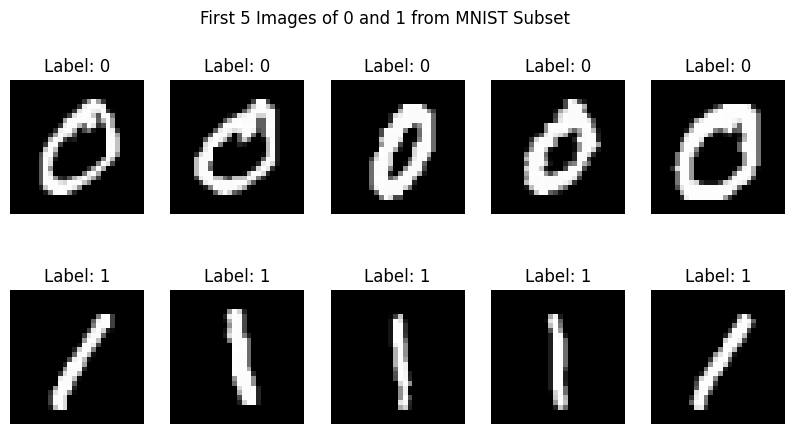

In [25]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [26]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

#  Question- 3: What does the weights array represent in this context?

The weights array has length 784, so it contains one weight for each pixel position in the flattened 28×28 image.
​

Each weight measures how strongly that pixel contributes to predicting class 1 versus class 0: positive weights push the prediction towards 1 when the pixel is active, and negative weights push it towards 0.
​

Together with the bias, the weight vector defines the linear decision boundary used by the perceptron to separate zeros and ones in the feature space.


# Question- 4: Why are we initializing the weights to zero? What effect could this have on the training process?

Initializing all weights to zero is simple and gives a neutral starting point where the model has no preference for any particular pixel.
​

In the perceptron algorithm, symmetry is quickly broken because each sample’s updates modify different weights based on its own pixel values.
​

As a result, zero initialization does not prevent the perceptron from learning; it just means the first updates are driven entirely by the early training examples.

## Step - 3 - Make a Decision function:

In [27]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all


## Step - 3 - Implement the Perceptron Learning Algorithm

In [36]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (n_samples, n_features)
    - y: Labels (n_samples,)
    - weights: Initial weights (n_features,)
    - bias: Initial bias (scalar)
    - learning_rate: Learning rate for updates
    - epochs: Number of passes over the data

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Final accuracy on the training set
    """
    n_samples = X.shape[0]

    for epoch in range(1, epochs + 1):
        for i in range(n_samples):
            # Linear output
            linear_output = np.dot(X[i], weights) + bias

            # Step activation: >= 0 -> 1, else 0
            y_pred = 1 if linear_output >= 0 else 0

            # Update only if prediction is wrong
            if y_pred != y[i]:
                update = learning_rate * (y[i] - y_pred)
                weights += update * X[i]
                bias += update

        # Compute accuracy after this epoch
        y_pred_all = decision_function(X, weights, bias)
        accuracy = np.mean(y_pred_all == y)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Accuracy = {accuracy:.4f}")

    # Final accuracy
    accuracy = np.mean(decision_function(X, weights, bias) == y)
    return weights, bias, accuracy


# Question-5: What is the purpose of the output=np.dot(X[i],weights)+biasline?

This line computes the net input
z
z for the i‑th sample by taking the weighted sum of its features plus the bias term.
​

The dot product np.dot(X[i], weights) aggregates all 784 pixel values using their corresponding weights into a single scalar score.
​

Adding the bias shifts the decision boundary and allows the perceptron to correctly classify data that is not centered at the origin.


# Question- 6: What happens when the prediction is wrong? How are the weights and bias updated?

When the predicted label y_pred does not match the true label y[i], the algorithm applies the perceptron learning rule to correct the model.
​

The update term is learning_rate * (y[i] - y_pred), which is positive if we predicted 0 instead of 1 and negative if we predicted 1 instead of 0.
​

The weights are updated as weights += update * X[i], meaning we move the weight vector in the direction of the current sample if it belongs to class 1, or away from it if it belongs to class 0.
​

The bias is updated as bias += update, which shifts the decision boundary globally to reduce the error on this sample.


# Question- 7: Why is the final accuracy important, and what do you expect it to be?

Final accuracy summarizes how many training examples are classified correctly after the full training process, so it is a simple measure of how well the perceptron has learned the task.
​

For this 0 vs 1 subset of MNIST, we expect the classes to be linearly separable or nearly separable, so a well‑trained perceptron should achieve accuracy very close to 1.0.
​

In your run, the reported final accuracy is exactly 1.0, which means the perceptron found a separating hyperplane that classifies all training samples correctly.

## Training the Perceptron

In [29]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 10: Accuracy = 0.9992
Epoch 20: Accuracy = 1.0000
Epoch 30: Accuracy = 1.0000
Epoch 40: Accuracy = 1.0000
Epoch 50: Accuracy = 1.0000
Epoch 60: Accuracy = 1.0000
Epoch 70: Accuracy = 1.0000
Epoch 80: Accuracy = 1.0000
Epoch 90: Accuracy = 1.0000
Epoch 100: Accuracy = 1.0000
The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [30]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


#  Question- 8: What does misclassified idx store, and how is it used in this code?

misclassified_idx = np.where(y_pred != y)[0] stores the indices of all samples where the predicted label y_pred does not equal the true label y.
​

These indices are then used to select the corresponding rows from X, so the notebook can plot the images that were misclassified by the perceptron.
​

By visualizing those images, we can inspect which digits are confusing for the model and understand its limitations.

# Question- 9: How do you interpret the result if the output is ”All images were correctly classified!”?

The message “All images were correctly classified!” appears when misclassified_idx is empty, meaning there are no indices where y_pred and y differ.
​

This implies that, on the training set, the perceptron achieved 100% accuracy and did not make any mistakes.
​

For 0 vs 1, this is expected because the classes are linearly separable in the feature space, so a linear classifier like the perceptron can perfectly separate them.

#  Task 3: Perceptron Algorithm for 3 vs 5 Classification.

# 1. Implement each Step as we implemented above.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the 3 vs 5 dataset
df_35 = pd.read_csv("/content/drive/My Drive/AI and Machine Learning/Workshop 3/mnist_3_and_5.csv")

# Separate features and labels
X_35 = df_35.drop(columns=["label"]).values
y_35 = df_35["label"].values

print("Feature matrix shape (3 vs 5):", X_35.shape)
print("Label vector shape (3 vs 5):", y_35.shape)


Feature matrix shape (3 vs 5): (2741, 784)
Label vector shape (3 vs 5): (2741,)


In [32]:
# Map 3 -> 0, 5 -> 1
y_35_bin = np.where(y_35 == 5, 1, 0)
print("Unique labels after mapping:", np.unique(y_35_bin))


Unique labels after mapping: [0 1]


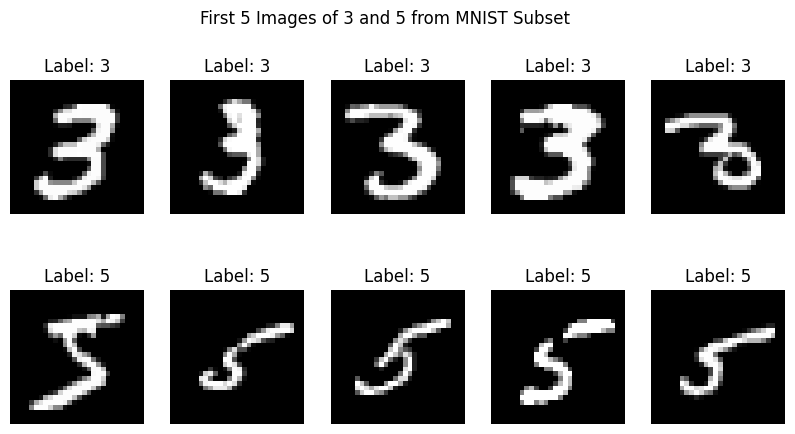

In [33]:
# Separate images for label 3 and label 5
images_3 = X_35[y_35 == 3]
images_5 = X_35[y_35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images in images_3 or images_5 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 3
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        # Plot digit 5
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()


In [34]:
# Step 3 – Initialize weights and bias for 3 vs 5
weights_35 = np.zeros(X_35.shape[1])  # one weight per pixel (784)
bias_35 = 0
learning_rate_35 = 0.1
epochs_35 = 100

print("Weights shape:", weights_35.shape)
print("Bias:", bias_35)


Weights shape: (784,)
Bias: 0


In [38]:
import numpy as np

def decisionfunction(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all


In [39]:
def trainperceptron(X, y, weights, bias, learningrate=0.1, epochs=100):
    n_samples = X.shape[0]

    for epoch in range(1, epochs + 1):
        for i in range(n_samples):
            linear_output = np.dot(X[i], weights) + bias
            y_pred = 1 if linear_output >= 0 else 0

            if y_pred != y[i]:
                update = learningrate * (y[i] - y_pred)
                weights += update * X[i]
                bias += update

        y_pred_all = decisionfunction(X, weights, bias)
        accuracy = np.mean(y_pred_all == y)
        if epoch % 10 == 0:
            print(f"Epoch {epoch} Accuracy {accuracy:.4f}")

    accuracy = np.mean(decisionfunction(X, weights, bias) == y)
    return weights, bias, accuracy


In [40]:
weights_35, bias_35, accuracy_35 = trainperceptron(
    X_35, y_35_bin,
    weights_35, bias_35,
    learningrate=learning_rate_35,
    epochs=epochs_35
)

print("Final training accuracy (3 vs 5):", accuracy_35)


Epoch 10 Accuracy 0.9613
Epoch 20 Accuracy 0.9540
Epoch 30 Accuracy 0.9730
Epoch 40 Accuracy 0.9730
Epoch 50 Accuracy 0.9518
Epoch 60 Accuracy 0.9515
Epoch 70 Accuracy 0.9770
Epoch 80 Accuracy 0.9861
Epoch 90 Accuracy 0.9829
Epoch 100 Accuracy 0.9869
Final training accuracy (3 vs 5): 0.986866107260124


Final Accuracy (3 vs 5): 0.9869


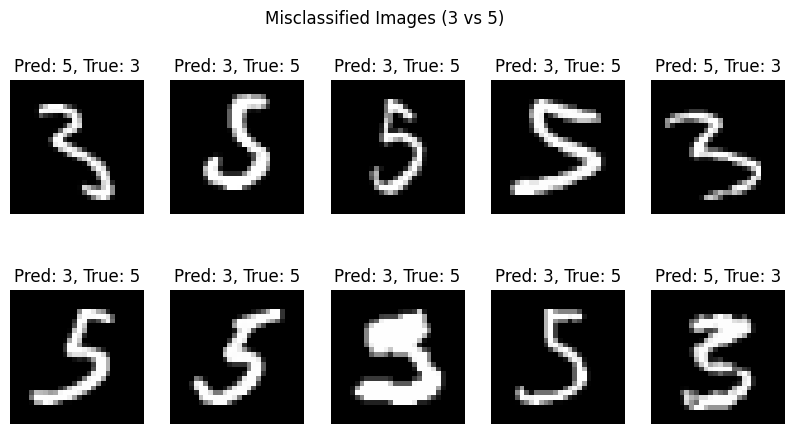

In [41]:
# Get predictions for all 3 vs 5 data points
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)

final_accuracy_35 = np.mean(y_pred_35 == y_35_bin)
print(f"Final Accuracy (3 vs 5): {final_accuracy_35:.4f}")

# Indices of misclassified samples
misclassified_idx_35 = np.where(y_pred_35 != y_35_bin)[0]

if len(misclassified_idx_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx_35[:10]):  # show up to 10
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        pred_label = 5 if y_pred_35[idx] == 1 else 3
        true_label = 5 if y_35_bin[idx] == 1 else 3
        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")


# Conclusion

For the 3 vs 5 perceptron, the final training accuracy was about 0.9869, which is slightly lower than the perfect 1.0 we achieved for 0 vs 1. This indicates that distinguishing between 3 and 5 is a harder problem and that these digits are not perfectly linearly separable in the pixel space. The misclassified images often look ambiguous, with shapes that could reasonably be interpreted as either 3 or 5 even by humans. This shows a limitation of a single‑layer perceptron: when classes overlap or are not strictly linearly separable, a linear decision boundary cannot classify all examples correctly.